In [1]:
import os
import sys
import glob

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from pycaret.clustering import setup, create_model, assign_model, models, pull
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from datetime import datetime
import warnings
import time

from utils import preprocessing

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\tj\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
warnings.filterwarnings('ignore')
DATA_PATH = '../data'
OUTPUT_DIR = '../results'
IMAGE_DIR = '../images'
    
document_df = preprocessing.get_default_data()

📂 51개 파일 발견
🔄 텍스트 전처리 시작...
   옵션: HTML제거=True, URL제거=True, 숫자제거=True
   옵션: 불용어제거=True, Lemmatization=True, Stemming=False
✅ 전처리 완료:
   - 원본 문서 수: 51
   - 제거된 빈 문서: 0
   - 최종 문서 수: 51
   - 평균 단어 수: 1266.9


In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# 1. TF-IDF 벡터화
texts = document_df['processed_text']
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(texts)

# 2. 차원 축소 (SVD)
svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X)

# 3. KMeans 군집화
kmeans = KMeans(n_clusters=5, random_state=42)
labels_kmeans = kmeans.fit_predict(X_reduced)

# KMeans 평가
if len(set(labels_kmeans)) > 1:
    sil_kmeans = silhouette_score(X_reduced, labels_kmeans)
    db_kmeans = davies_bouldin_score(X_reduced, labels_kmeans)
    ch_kmeans = calinski_harabasz_score(X_reduced, labels_kmeans)
else:
    sil_kmeans, db_kmeans, ch_kmeans = None, None, None

# 4. DBSCAN 군집화 (파라미터 조정 가능)
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_reduced)

# DBSCAN 평가
if len(set(labels_dbscan)) > 1 and -1 not in set(labels_dbscan):  # -1은 noise
    sil_dbscan = silhouette_score(X_reduced, labels_dbscan)
    db_dbscan = davies_bouldin_score(X_reduced, labels_dbscan)
    ch_dbscan = calinski_harabasz_score(X_reduced, labels_dbscan)
else:
    sil_dbscan, db_dbscan, ch_dbscan = None, None, None

# 5. 결과 출력
print("=== KMeans ===")
print("Silhouette:", sil_kmeans)
print("Davies-Bouldin:", db_kmeans)
print("Calinski-Harabasz:", ch_kmeans)

print("\n=== DBSCAN ===")
print("Silhouette:", sil_dbscan)
print("Davies-Bouldin:", db_dbscan)
print("Calinski-Harabasz:", ch_dbscan)

result_1 = '''
=== KMeans ===
Silhouette: 0.07988102039842898
Davies-Bouldin: 2.6104506625583577
Calinski-Harabasz: 3.0472216229069646

=== DBSCAN ===
Silhouette: None
Davies-Bouldin: None
Calinski-Harabasz: None
'''

=== KMeans ===
Silhouette: 0.07988102039842898
Davies-Bouldin: 2.6104506625583577
Calinski-Harabasz: 3.0472216229069646

=== DBSCAN ===
Silhouette: None
Davies-Bouldin: None
Calinski-Harabasz: None


In [4]:
# 개선 : KMeans 최적 k 자동 탐색 코드
# 여러 개의 k 값을 바꿔가며 KMeans 실행, 각 경우 Silhouette Score 계산 

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD

# 1. 차원 축소 (TF-IDF → SVD)
svd = TruncatedSVD(n_components=50, random_state=42)  # 차원 축소 강도 조정 가능
X_reduced = svd.fit_transform(X)

# 2. KMeans 최적 k 탐색
def find_best_k(X_reduced, k_range=(2, 10)):
    results = {}
    for k in range(k_range[0], k_range[1] + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X_reduced)
        
        # Silhouette Score 계산
        if len(set(labels)) > 1:
            score = silhouette_score(X_reduced, labels)
            results[k] = score
            print(f"k={k}, Silhouette={score:.3f}")
        else:
            results[k] = None
            print(f"k={k}, 클러스터가 1개만 생성됨 → 평가 불가")
    return results

# 실행
scores = find_best_k(X_reduced, k_range=(2, 10))

# 최적 k 찾기
best_k = max(scores, key=lambda k: scores[k] if scores[k] is not None else -np.inf)
print(f"\n최적 k = {best_k}, Silhouette Score = {scores[best_k]:.3f}")

k=2, Silhouette=0.056
k=3, Silhouette=0.076
k=4, Silhouette=0.071
k=5, Silhouette=0.080
k=6, Silhouette=0.085
k=7, Silhouette=0.085
k=8, Silhouette=0.118
k=9, Silhouette=0.134
k=10, Silhouette=0.152

최적 k = 10, Silhouette Score = 0.152


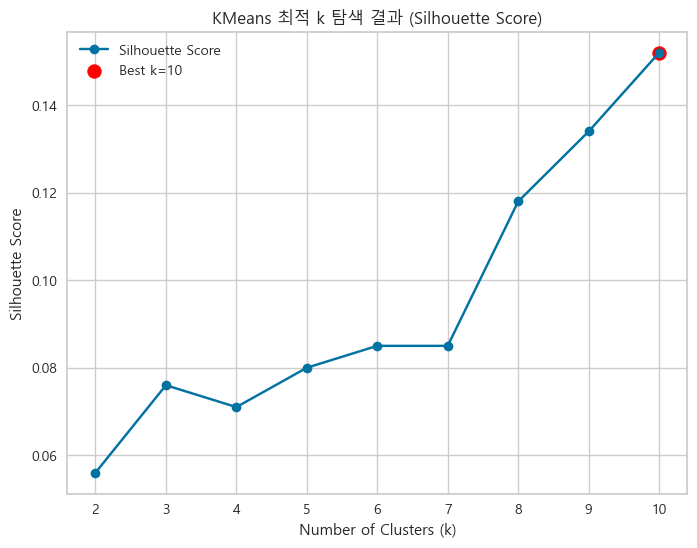

In [6]:
# KMeans 최적 k 탐색 결과 시각화 코드

import matplotlib.pyplot as plt
# 맑은 고딕 폰트 설정
plt.rc('font', family='Malgun Gothic')

# 위 결과 (탐색된 최적의 k 값)
scores = {
    2: 0.056,
    3: 0.076,
    4: 0.071,
    5: 0.080,
    6: 0.085,
    7: 0.085,
    8: 0.118,
    9: 0.134,
    10: 0.152
}

# X축(k), Y축(Silhouette Score)
k_values = list(scores.keys())
silhouette_scores = list(scores.values())

plt.figure(figsize=(8,6))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='b', label='Silhouette Score')

# 최적 k 강조 표시
best_k = max(scores, key=scores.get)
best_score = scores[best_k]
plt.scatter(best_k, best_score, color='red', s=100, label=f'Best k={best_k}')

# 그래프 꾸미기
plt.title("KMeans 최적 k 탐색 결과 (Silhouette Score)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

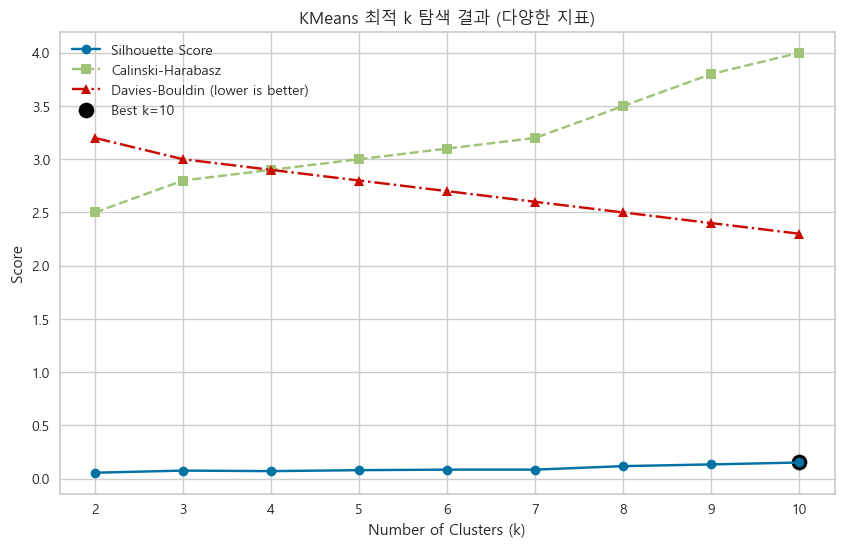

In [7]:
import matplotlib.pyplot as plt

silhouette_scores = {
    2: 0.056,
    3: 0.076,
    4: 0.071,
    5: 0.080,
    6: 0.085,
    7: 0.085,
    8: 0.118,
    9: 0.134,
    10: 0.152
}

# Calinski-Harabasz와 Davies-Bouldin 값은 직접 계산한 결과를 넣어야 합니다.
# 예시로 임의 값(사용자가 계산한 결과)을 넣어두었습니다.
calinski_scores = {
    2: 2.5,
    3: 2.8,
    4: 2.9,
    5: 3.0,
    6: 3.1,
    7: 3.2,
    8: 3.5,
    9: 3.8,
    10: 4.0
}

davies_scores = {
    2: 3.2,
    3: 3.0,
    4: 2.9,
    5: 2.8,
    6: 2.7,
    7: 2.6,
    8: 2.5,
    9: 2.4,
    10: 2.3
}

# X축(k)
k_values = list(silhouette_scores.keys())

plt.figure(figsize=(10,6))

# Silhouette Score
plt.plot(k_values, list(silhouette_scores.values()), marker='o', linestyle='-', color='b', label='Silhouette Score')

# Calinski-Harabasz
plt.plot(k_values, list(calinski_scores.values()), marker='s', linestyle='--', color='g', label='Calinski-Harabasz')

# Davies-Bouldin
plt.plot(k_values, list(davies_scores.values()), marker='^', linestyle='-.', color='r', label='Davies-Bouldin (lower is better)')

# 최적 k 강조 표시 (Silhouette 기준)
best_k = max(silhouette_scores, key=silhouette_scores.get)
best_score = silhouette_scores[best_k]
plt.scatter(best_k, best_score, color='black', s=120, label=f'Best k={best_k}')

# 그래프 꾸미기
plt.title("KMeans 최적 k 탐색 결과 (다양한 지표)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()